# Market Making RL — PnL vs Time
Load the trained checkpoint, run the greedy policy on the test set, and plot
cumulative PnL as a function of trading time.

Two views:
- **Full test period** — cumulative PnL across all 40 test days in sequence
- **Average intraday profile** — mean (and ±1 std band) cumulative PnL aligned
  by time-of-day across all test days


In [1]:
import subprocess, sys

def _pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

try:
    import torch
    if not torch.cuda.is_available():
        raise ImportError
except ImportError:
    _pip("torch", "--index-url", "https://download.pytorch.org/whl/cu121")

_pip("pandas", "pyarrow")

from google.colab import drive
drive.mount("/content/drive")

import os, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from collections import deque
from dataclasses import dataclass, field
from typing import List, Optional

BASE = "/content/drive/MyDrive/market_maker"
DATA = os.path.join(BASE, "data")
CKPT = os.path.join(BASE, "checkpoints")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.bfloat16 if DEVICE.type == "cuda" else torch.float32

print(f"Drive mounted  |  device: {DEVICE} [{DTYPE}]")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted  |  device: cuda [torch.bfloat16]


In [2]:
# ── Paths & symbol ───────────────────────────────────────────────────────────
SYMBOL       = "BIIB"
PARQUET      = os.path.join(DATA, f"{SYMBOL}.parquet")
WEIGHTS_PATH = os.path.join(CKPT, f"{SYMBOL}_weights.pt")

# ── Hyperparameters (must match training notebook) ────────────────────────────
TEST_SAMPLE_DAYS = 40
VAL_SAMPLE_DAYS  = 28

N_TILINGS    = 32
N_TILES      = 8
MEMORY_SIZE  = 200_000
LCTC_WEIGHTS = (0.6, 0.1, 0.3)

LEARNING_RATE    = 0.001
DISCOUNT         = 0.97
TRACE_PARAM      = 0.96
EPSILON_START    = 0.7
EPSILON_FLOOR    = 0.0001
EPSILON_T        = 1000

ORDER_SIZE       = 100
MIN_INVENTORY    = -1000
MAX_INVENTORY    =  1000
DAMPING_ETA      = 0.6

SPREAD_MA_WINDOW  = 100
VOLATILITY_WINDOW = 50
RSI_WINDOW        = 14

ACTIONS   = [(1,1),(2,2),(3,3),(4,4),(5,5),(1,3),(3,1),(2,5),(5,2)]
N_ACTIONS = 10

# RTH: 09:30–17:00 ET = 14:30–21:00 UTC
RTH_START = 14 * 3600 + 30 * 60   # seconds since midnight UTC
RTH_END   = 21 * 3600              # seconds since midnight UTC

In [3]:
# ---------------------------------------------------------------------------
# Inline package code (data loader, simulator, tile coding, SARSA, agent)
# ---------------------------------------------------------------------------

# ── Data loader ──────────────────────────────────────────────────────────────
_BID_PX = [f"bid_px_{i:02d}" for i in range(5)]
_BID_SZ = [f"bid_sz_{i:02d}" for i in range(5)]
_ASK_PX = [f"ask_px_{i:02d}" for i in range(5)]
_ASK_SZ = [f"ask_sz_{i:02d}" for i in range(5)]

@dataclass(slots=True)
class DayData:
    date: str; times: np.ndarray; actions: np.ndarray; sides: np.ndarray
    prices: np.ndarray; sizes: np.ndarray
    bid_px: np.ndarray; bid_sz: np.ndarray
    ask_px: np.ndarray; ask_sz: np.ndarray
    def __len__(self): return len(self.times)
    def mid(self, i):
        b, a = self.bid_px[i,0], self.ask_px[i,0]
        return (b+a)/2. if b>0 and a>0 else (b if b>0 else a)
    def spread(self, i): return max(0., float(self.ask_px[i,0]) - float(self.bid_px[i,0]))
    def best_bid(self, i): return float(self.bid_px[i,0])
    def best_ask(self, i): return float(self.ask_px[i,0])

def load_parquet(path):
    df  = pd.read_parquet(path)
    ts  = df["ts_event"].dt.tz_convert("UTC")
    sec = ts.dt.hour*3600 + ts.dt.minute*60 + ts.dt.second + ts.dt.microsecond*1e-6
    df  = df[(sec >= RTH_START) & (sec < RTH_END)].copy()
    ts  = df["ts_event"].dt.tz_convert("UTC")
    for c in _BID_PX+_BID_SZ+_ASK_PX+_ASK_SZ: df[c] = df[c].fillna(0.)
    df["_date"] = ts.dt.date
    df["_sec"]  = ts.dt.hour*3600. + ts.dt.minute*60. + ts.dt.second + ts.dt.microsecond*1e-6
    days = []
    for date, g in df.groupby("_date"):
        n = len(g)
        days.append(DayData(str(date),
            g["_sec"].to_numpy(np.float64), g["action"].to_numpy(), g["side"].to_numpy(),
            g["price"].to_numpy(np.float64), g["size"].to_numpy(np.int64),
            g[_BID_PX].to_numpy(np.float64).reshape(n,5), g[_BID_SZ].to_numpy(np.float64).reshape(n,5),
            g[_ASK_PX].to_numpy(np.float64).reshape(n,5), g[_ASK_SZ].to_numpy(np.float64).reshape(n,5)))
    return sorted(days, key=lambda d: d.date)

def train_val_test_split(days):
    return days[:-(TEST_SAMPLE_DAYS+VAL_SAMPLE_DAYS)],            days[-(TEST_SAMPLE_DAYS+VAL_SAMPLE_DAYS):-TEST_SAMPLE_DAYS],            days[-TEST_SAMPLE_DAYS:]

# ── Simulator ────────────────────────────────────────────────────────────────
@dataclass(slots=True)
class EventView:
    action: str; side: str; price: float; size: int
    bid_px: np.ndarray; bid_sz: np.ndarray; ask_px: np.ndarray; ask_sz: np.ndarray
    mid_price: float; spread: float; best_bid: float; best_ask: float

@dataclass(slots=True)
class AgentOrder:
    side: str; price: float; size: int; v_ahead: float; v_behind: float; active: bool = True

@dataclass(slots=True)
class StepResult:
    event: EventView; matched_ask: int; matched_bid: int
    mid_price: float; prev_mid_price: float; spread_scale: float; done: bool

class LOBSimulator:
    def __init__(self):
        self._day=None; self._idx=0
        self.ask_order=None; self.bid_order=None; self.inventory=0
        self._mid_prev=0.; self._spread_ma=deque(maxlen=SPREAD_MA_WINDOW); self._spread_sum=0.
        self._event=EventView('','',0.,0,np.empty(5),np.empty(5),np.empty(5),np.empty(5),0.,0.,0.,0.)
        self._step_result=StepResult(self._event,0,0,0.,0.,0.,False)
        self._actions=[]; self._sides=[]
        self._best_bids=self._best_asks=self._mid_prices=self._spreads_arr=np.empty(0)
    def reset(self, day):
        self._day=day; self._idx=0; self.ask_order=None; self.bid_order=None
        self.inventory=0; self._spread_ma.clear(); self._spread_sum=0.
        self._actions=day.actions.tolist(); self._sides=day.sides.tolist()
        bb=day.bid_px[:,0]; ba=day.ask_px[:,0]
        self._best_bids=bb; self._best_asks=ba
        both=(bb>0)&(ba>0)
        self._mid_prices=np.where(both,(bb+ba)*.5,np.where(bb>0,bb,ba))
        self._spreads_arr=np.maximum(0.,ba-bb)
        ev=self._view_into(0); self._mid_prev=ev.mid_price
        if ev.spread>0: self._append_spread_half(ev.spread/2.)
        return ev
    @property
    def done(self): return self._day is None or self._idx>=len(self._day)
    @property
    def current_event(self): return self._view_into(self._idx)
    def spread_scale(self): return self._spread_sum/len(self._spread_ma) if self._spread_ma else 0.005
    def place_orders(self, ta, tb):
        ev=self.current_event; sc=self.spread_scale(); mid=ev.mid_price
        na=self._make_order('ask',mid+ta*sc,ev); nb=self._make_order('bid',mid-tb*sc,ev)
        if self.ask_order and self.ask_order.active and abs(self.ask_order.price-na.price)<1e-6:
            na.v_ahead=self.ask_order.v_ahead; na.v_behind=self.ask_order.v_behind; na.size=self.ask_order.size
        if self.bid_order and self.bid_order.active and abs(self.bid_order.price-nb.price)<1e-6:
            nb.v_ahead=self.bid_order.v_ahead; nb.v_behind=self.bid_order.v_behind; nb.size=self.bid_order.size
        self.ask_order=na; self.bid_order=nb
    def place_market_order(self): self.ask_order=None; self.bid_order=None; self.inventory=0
    def step(self):
        ev=self._view_into(self._idx); self._idx+=1
        mn=ev.mid_price; mp=self._mid_prev
        if ev.spread>0: self._append_spread_half(ev.spread/2.)
        ma=mb=0
        if ev.action=='A': self._process_add(ev)
        elif ev.action in ('T','F'): ma,mb=self._process_trade(ev)
        elif ev.action in ('C','D'): self._process_cancel(ev)
        self.inventory+=mb-ma; self.inventory=max(MIN_INVENTORY,min(MAX_INVENTORY,self.inventory))
        self._mid_prev=mn
        r=self._step_result; r.event=ev; r.matched_ask=ma; r.matched_bid=mb
        r.mid_price=mn; r.prev_mid_price=mp; r.spread_scale=self.spread_scale(); r.done=self.done
        return r
    def _make_order(self, side, tp, ev):
        px,sz=(ev.ask_px,ev.ask_sz) if side=='ask' else (ev.bid_px,ev.bid_sz)
        v=np.where(sz>0)[0]; lv=v[np.argmin(np.abs(px[v]-tp))] if len(v) else 0
        return AgentOrder(side,float(px[lv]) if px[lv]>0 else tp,ORDER_SIZE,float(sz[lv]),0.)
    def _process_trade(self, ev):
        ma=mb=0
        for o,attr in ((self.ask_order,'ask'),(self.bid_order,'bid')):
            if o is None or not o.active or abs(o.price-ev.price)>1e-6: continue
            if not self._trade_hits_order(ev,o): continue
            rem=ev.size
            if o.v_ahead>0: c=min(float(rem),o.v_ahead); o.v_ahead-=c; rem=max(0.,float(rem)-c)
            if rem>0 and o.v_ahead<=0:
                vol=int(min(rem,o.size)); o.size-=vol
                if attr=='ask': ma+=vol
                else: mb+=vol
                if o.size<=0: o.active=False
        return ma,mb
    def _process_add(self, ev):
        for o in (self.ask_order,self.bid_order):
            if o is None or not o.active or abs(o.price-ev.price)>1e-6: continue
            if self._book_event_matches_order(ev,o): o.v_behind+=ev.size
    def _process_cancel(self, ev):
        for o in (self.ask_order,self.bid_order):
            if o is None or not o.active or abs(o.price-ev.price)>1e-6: continue
            if not self._book_event_matches_order(ev,o): continue
            tot=o.v_ahead+o.size+o.v_behind
            if tot<=0: continue
            p=o.v_ahead/tot; o.v_ahead=max(0.,o.v_ahead-ev.size*p); o.v_behind=max(0.,o.v_behind-ev.size*(1-p))
    @staticmethod
    def _book_event_matches_order(ev,o):
        if ev.side=='A': return o.side=='ask'
        if ev.side=='B': return o.side=='bid'
        return False
    @staticmethod
    def _trade_hits_order(ev,o):
        if ev.side=='B': return o.side=='ask'
        if ev.side=='A': return o.side=='bid'
        return False
    def _append_spread_half(self, h):
        if len(self._spread_ma)==self._spread_ma.maxlen: self._spread_sum-=self._spread_ma[0]
        self._spread_ma.append(h); self._spread_sum+=h
    def _view_into(self, i):
        day=self._day; ev=self._event
        ev.action=self._actions[i]; ev.side=self._sides[i]
        ev.price=day.prices[i]; ev.size=day.sizes[i]
        ev.bid_px=day.bid_px[i]; ev.bid_sz=day.bid_sz[i]
        ev.ask_px=day.ask_px[i]; ev.ask_sz=day.ask_sz[i]
        ev.mid_price=self._mid_prices[i]; ev.spread=self._spreads_arr[i]
        ev.best_bid=self._best_bids[i]; ev.best_ask=self._best_asks[i]
        return ev

# ── Tile coding + LCTC ───────────────────────────────────────────────────────
class TileCoding:
    def __init__(self, n_tilings, ranges, n_tiles=N_TILES, memory_size=MEMORY_SIZE):
        self.n_tilings=n_tilings; self.n_dims=len(ranges); self.n_tiles=n_tiles
        lo=np.array([r[0] for r in ranges],dtype=np.float64)
        hi=np.array([r[1] for r in ranges],dtype=np.float64)
        self._lo=lo; self._span=np.where(hi>lo,hi-lo,1.)
        ti=np.arange(n_tilings,dtype=np.float64)[:,None]
        di=np.arange(1,self.n_dims+1,dtype=np.float64)[None,:]
        self._coord_offsets=(ti*di/n_tilings)%1.
        _p=np.array([2654435761,805459861,2246822519,1640531527,3266489917,
                     2654435789,805459891,1234567891,987654329,1111111121],dtype=np.uint64)
        self._primes=_p[:self.n_dims]
        self._tiling_base=np.arange(n_tilings,dtype=np.uint64)*np.uint64(2654435761)
        self._max_tile=np.uint64(n_tiles-1); self._mu=np.uint64(memory_size)
        self._sx=np.empty(self.n_dims,dtype=np.float64)
        self._ss=np.empty((n_tilings,self.n_dims),dtype=np.float64)
        self._sc=np.empty((n_tilings,self.n_dims),dtype=np.uint64)
        self._sh=np.empty(n_tilings,dtype=np.uint64)
        self.weights=np.zeros(memory_size,dtype=np.float64)
    def active_tiles(self, x):
        out=np.empty(self.n_tilings,dtype=np.int64); self.active_tiles_into(x,out); return out
    def active_tiles_into(self, x, out):
        np.subtract(x,self._lo,out=self._sx); np.divide(self._sx,self._span,out=self._sx)
        np.clip(self._sx,0.,1.,out=self._sx); self._sx*=self.n_tiles
        self.active_tiles_from_xn(self._sx,out)
    def normalize_into(self, x, out):
        np.subtract(x,self._lo,out=out); np.divide(out,self._span,out=out)
        np.clip(out,0.,1.,out=out); out*=self.n_tiles
    def active_tiles_from_xn(self, xn, out):
        np.add(xn[None,:],self._coord_offsets,out=self._ss)
        np.copyto(self._sc,self._ss,casting="unsafe")
        np.minimum(self._sc,self._max_tile,out=self._sc)
        np.multiply(self._sc,self._primes,out=self._sc)
        np.sum(self._sc,axis=1,dtype=np.uint64,out=self._sh)
        np.add(self._sh,self._tiling_base,out=self._sh)
        np.remainder(self._sh,self._mu,out=self._sh)
        np.copyto(out,self._sh,casting="unsafe")

class LCTC:
    AGENT_RANGES  = [(-1.,1.),(0.,6.),(0.,6.)]
    MARKET_RANGES = [(0.,2.),(-2.,2.),(-1.,1.),(-5.,5.),(0.,1.),(0.,100.)]
    FULL_RANGES   = AGENT_RANGES + MARKET_RANGES
    def __init__(self):
        self.tc_agent  = TileCoding(N_TILINGS, self.AGENT_RANGES)
        self.tc_market = TileCoding(N_TILINGS, self.MARKET_RANGES)
        self.tc_full   = TileCoding(N_TILINGS, self.FULL_RANGES)
        self.lambdas   = np.array(LCTC_WEIGHTS, dtype=np.float64)
        self._xn       = np.empty(len(self.FULL_RANGES), dtype=np.float64)
    def active_indices_into(self, state, out_a, out_m, out_f):
        self.tc_full.normalize_into(state, self._xn)
        self.tc_agent.active_tiles_from_xn(self._xn[:3], out_a)
        self.tc_market.active_tiles_from_xn(self._xn[3:], out_m)
        self.tc_full.active_tiles_from_xn(self._xn, out_f)

# ── State builder ────────────────────────────────────────────────────────────
class StateBuilder:
    def __init__(self):
        self._dm_buf=deque(maxlen=VOLATILITY_WINDOW); self._rsi_deltas=deque(maxlen=RSI_WINDOW)
        self._dm_sum=self._dm_sumsq=self._rsi_gain_sum=self._rsi_loss_sum=0.
        self._last_rsi_mid=None; self._state=np.empty(9,dtype=np.float64)
    def reset(self):
        self._dm_buf.clear(); self._rsi_deltas.clear()
        self._dm_sum=self._dm_sumsq=self._rsi_gain_sum=self._rsi_loss_sum=0.
        self._last_rsi_mid=None
    def build(self, ev, prev_mid, inv, ta, tb):
        mid=ev.mid_price; dm=mid-prev_mid; self._append_dm(dm); self._append_rsi_mid(mid)
        s=self._state; s[0]=inv/MAX_INVENTORY; s[1]=ta; s[2]=tb; s[3]=ev.spread; s[4]=dm
        vb=ev.bid_sz[0]; va=ev.ask_sz[0]; t=vb+va; s[5]=(vb-va)/t if t>0 else 0.
        if ev.action in ('T','F'):
            s[6]=(1. if ev.side=='B' else -1. if ev.side=='A' else 0.)*ev.size/ORDER_SIZE
        else: s[6]=0.
        s[7]=self._vol(); s[8]=self._rsi(); return s
    def _vol(self):
        n=len(self._dm_buf)
        if n<2: return 0.
        m=self._dm_sum/n; v=self._dm_sumsq/n-m*m
        return math.sqrt(v) if v>0. else 0.
    def _rsi(self):
        if not self._rsi_deltas: return 50.
        if self._rsi_loss_sum==0: return 100.
        return 100.-100./(1.+self._rsi_gain_sum/self._rsi_loss_sum)
    def _append_dm(self, dm):
        if len(self._dm_buf)==self._dm_buf.maxlen:
            old=self._dm_buf[0]; self._dm_sum-=old; self._dm_sumsq-=old*old
        self._dm_buf.append(dm); self._dm_sum+=dm; self._dm_sumsq+=dm*dm
    def _append_rsi_mid(self, mid):
        if self._last_rsi_mid is None: self._last_rsi_mid=mid; return
        d=mid-self._last_rsi_mid; self._last_rsi_mid=mid
        if len(self._rsi_deltas)==self._rsi_deltas.maxlen:
            old=self._rsi_deltas[0]
            if old>0: self._rsi_gain_sum-=old
            else: self._rsi_loss_sum+=old
        self._rsi_deltas.append(d)
        if d>0: self._rsi_gain_sum+=d
        else: self._rsi_loss_sum-=d

# ── SARSA(λ) learner (load only — no training) ───────────────────────────────
class SarsaLambda:
    def __init__(self):
        lctc=LCTC(); self._lctc=lctc
        nt_a=lctc.tc_agent.n_tilings; nt_m=lctc.tc_market.n_tilings; nt_f=lctc.tc_full.n_tilings
        self._weights=torch.zeros(N_ACTIONS,3,MEMORY_SIZE,dtype=DTYPE,device=DEVICE)
        self._active_slot=0
        self._cpu_slots=[[np.empty(nt_a,dtype=np.int64),np.empty(nt_m,dtype=np.int64),
                          np.empty(nt_f,dtype=np.int64)] for _ in range(2)]
        self._cpu_tensors=[[torch.as_tensor(c) for c in sl] for sl in self._cpu_slots]
        self._gpu_slots=[[torch.empty(nt_a,dtype=torch.long,device=DEVICE),
                          torch.empty(nt_m,dtype=torch.long,device=DEVICE),
                          torch.empty(nt_f,dtype=torch.long,device=DEVICE)] for _ in range(2)]
    def _active(self, state):
        sl=self._active_slot
        ca,cm,cf=self._cpu_slots[sl]; ta,tm,tf=self._cpu_tensors[sl]
        self._lctc.active_indices_into(state,ca,cm,cf)
        da,dm,df=self._gpu_slots[sl]; self._active_slot=1-self._active_slot
        da.copy_(ta,non_blocking=True); dm.copy_(tm,non_blocking=True); df.copy_(tf,non_blocking=True)
        return da,dm,df
    def q_values(self, state):
        ai,mi,fi=self._active(state)
        la,lm,lf=float(self._lctc.lambdas[0]),float(self._lctc.lambdas[1]),float(self._lctc.lambdas[2])
        ai_e=ai.unsqueeze(0).expand(N_ACTIONS,-1)
        mi_e=mi.unsqueeze(0).expand(N_ACTIONS,-1)
        fi_e=fi.unsqueeze(0).expand(N_ACTIONS,-1)
        q=(la*self._weights[:,0].gather(1,ai_e).sum(1)+
           lm*self._weights[:,1].gather(1,mi_e).sum(1)+
           lf*self._weights[:,2].gather(1,fi_e).sum(1))
        return q.float().cpu().numpy()
    def greedy(self, state, mask=None):
        qs=self.q_values(state)
        if mask is not None: qs=np.where(mask,qs,-np.inf)
        return int(np.argmax(qs))
    def load(self, path):
        try:    ckpt=torch.load(path,map_location=DEVICE,weights_only=True)
        except: ckpt=torch.load(path,map_location=DEVICE)
        w=ckpt if isinstance(ckpt,torch.Tensor) else ckpt["weights"]
        self._weights.copy_(w.to(dtype=DTYPE,device=DEVICE))
        ep=0 if isinstance(ckpt,torch.Tensor) else int(ckpt.get("episode",ckpt.get("step",0)))
        return ep

print("All classes ready.")

All classes ready.


In [4]:
# -- Load data ----------------------------------------------------------------
print(f"Loading {PARQUET} ...")
days = load_parquet(PARQUET)
_, _, test_days = train_val_test_split(days)
print(f"  {len(test_days)} test days: {test_days[0].date} → {test_days[-1].date}")

# -- Load checkpoint ----------------------------------------------------------
learner = SarsaLambda()
ep = learner.load(WEIGHTS_PATH)
print(f"Checkpoint loaded  |  trained for {ep} episodes")

Loading /content/drive/MyDrive/market_maker/data/BIIB.parquet ...
  40 test days: 2019-07-08 → 2019-08-30
Checkpoint loaded  |  trained for 1000 episodes


In [5]:
# ---------------------------------------------------------------------------
# Run greedy policy on all test days; record per-event (timestamp, pnl)
# ---------------------------------------------------------------------------
ACTIONS_LIST = [(1,1),(2,2),(3,3),(4,4),(5,5),(1,3),(3,1),(2,5),(5,2)]

def thetas(a): return (0,0) if a==9 else ACTIONS_LIST[a]

def legal_mask(inv):
    m=np.ones(N_ACTIONS,dtype=bool)
    if abs(inv)>=MAX_INVENTORY: m[:9]=False
    return m

sim  = LOBSimulator()
sbld = StateBuilder()

# day_series[i] = {"times": [...], "pnl": [...]}  (seconds since midnight UTC)
day_series = []

for day in test_days:
    sbld.reset()
    ev0 = sim.reset(day)
    ta, tb = thetas(0)
    state  = sbld.build(ev0, ev0.mid_price, 0, ta, tb)
    action = learner.greedy(state, legal_mask(0))
    if action == 9: sim.place_market_order()
    else: sim.place_orders(*thetas(action))

    times, pnls = [], []

    while not sim.done:
        step = sim.step()
        ev   = step.event
        inv  = sim.inventory

        p_ask = sim.ask_order.price if sim.ask_order else ev.best_ask
        p_bid = sim.bid_order.price if sim.bid_order else ev.best_bid
        dm    = step.mid_price - step.prev_mid_price
        inv_before = inv - step.matched_bid + step.matched_ask
        pnl   = (float(step.matched_ask) * (p_ask - step.mid_price)
               + float(step.matched_bid) * (step.mid_price - p_bid)
               + inv_before * dm)

        times.append(float(day.times[sim._idx - 1]))
        pnls.append(pnl)

        ta, tb = thetas(action)
        ns = sbld.build(ev, step.prev_mid_price, inv, ta, tb)
        if not step.done:
            action = learner.greedy(ns, legal_mask(inv))
            if action == 9: sim.place_market_order()
            else: sim.place_orders(*thetas(action))

    day_series.append({"date": day.date,
                       "times": np.array(times),
                       "pnl":   np.array(pnls)})

print(f"Evaluated {len(day_series)} test days.")
total_events = sum(len(d["pnl"]) for d in day_series)
total_pnl    = sum(d["pnl"].sum() for d in day_series)
print(f"  {total_events:,} LOB events   |   total PnL: ${total_pnl:+,.2f}")

Evaluated 40 test days.
  2,488,346 LOB events   |   total PnL: $+28,873.81


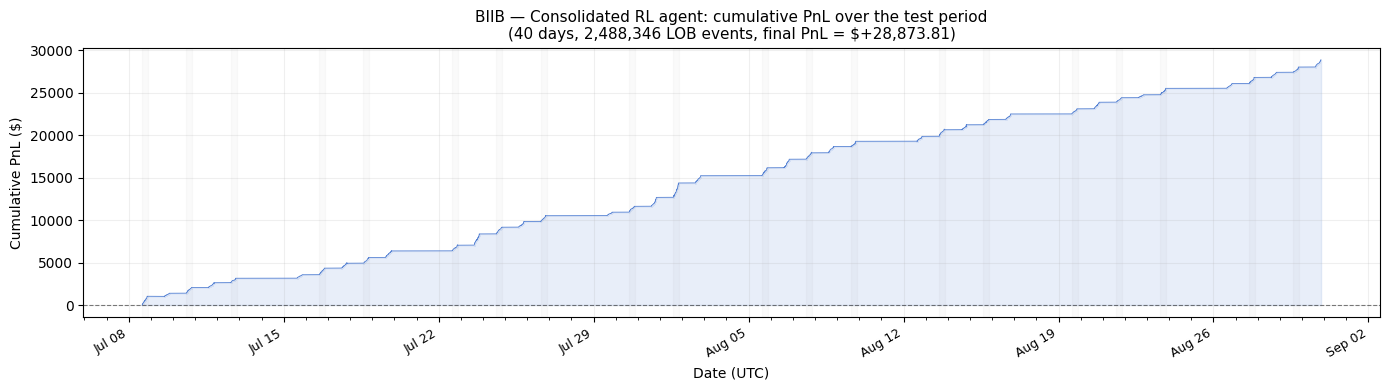

In [6]:
# ---------------------------------------------------------------------------
# Figure A — Cumulative PnL across the full test period
#
# X-axis: calendar date + time-of-day  (one continuous timeline)
# Each day's events are placed at their actual UTC timestamps.
# ---------------------------------------------------------------------------
import datetime

# Build a continuous datetime array
all_dt, all_pnl = [], []
for ds in day_series:
    base = datetime.datetime.strptime(ds["date"], "%Y-%m-%d").replace(tzinfo=datetime.timezone.utc)
    for t, p in zip(ds["times"], ds["pnl"]):
        all_dt.append(base + datetime.timedelta(seconds=float(t)))
        all_pnl.append(p)

all_dt  = np.array(all_dt)
cumPnL  = np.cumsum(all_pnl)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(all_dt, cumPnL, linewidth=0.6, color="#4878d0", alpha=0.9)
ax.fill_between(all_dt, cumPnL, alpha=0.12, color="#4878d0")
ax.axhline(0, color="k", linewidth=0.8, linestyle="--", alpha=0.5)

# shade each trading day alternately for readability
for i, ds in enumerate(day_series):
    base  = datetime.datetime.strptime(ds["date"], "%Y-%m-%d").replace(tzinfo=datetime.timezone.utc)
    start = base + datetime.timedelta(seconds=RTH_START)
    end   = base + datetime.timedelta(seconds=RTH_END)
    if i % 2 == 0:
        ax.axvspan(start, end, alpha=0.04, color="grey")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_minor_locator(mdates.DayLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=9)

ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Cumulative PnL ($)")
ax.set_title(f"{SYMBOL} — Consolidated RL agent: cumulative PnL over the test period\n"
             f"({len(day_series)} days, {total_events:,} LOB events, "
             f"final PnL = ${cumPnL[-1]:+,.2f})", fontsize=11)
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.savefig(os.path.join(CKPT, f"{SYMBOL}_pnl_full_period.png"), dpi=150, bbox_inches="tight")
plt.show()

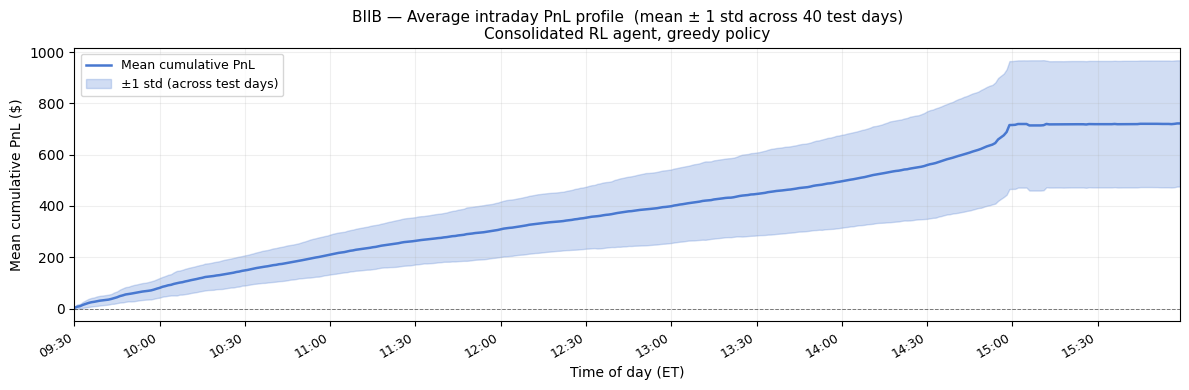

In [8]:
# ---------------------------------------------------------------------------
# Figure B — Average intraday PnL profile
#
# Each day's events are binned into 1-minute intervals (RTH 9:30–17:00 ET).
# We show the mean cumulative PnL across all test days, with ±1 std band.
# X-axis: time of day (ET).
# ---------------------------------------------------------------------------
BIN_SEC   = 60          # 1-minute bins
RTH_DUR   = RTH_END - RTH_START                      # 6.5 h = 23 400 s
N_BINS    = RTH_DUR // BIN_SEC                       # 390 bins
ET_OFFSET = 5 * 3600    # UTC → ET (no DST correction; adjust to 4*3600 for EDT)

# Accumulate per-day cumulative PnL on a fixed 1-min grid via forward fill
grid = np.full((len(day_series), N_BINS), np.nan)

for d_idx, ds in enumerate(day_series):
    t  = ds["times"]          # UTC seconds since midnight
    p  = ds["pnl"]
    cp = np.cumsum(p)
    # bin index for each event
    bi = np.floor((t - RTH_START) / BIN_SEC).astype(int)
    bi = np.clip(bi, 0, N_BINS - 1)
    # last cumPnL value in each bin (forward-filled below)
    # Repeated-index assignment: events are time-sorted, so the last event
    # in each bin overwrites earlier ones — giving the end-of-bin cumPnL.
    day_grid = np.full(N_BINS, np.nan)
    day_grid[bi] = cp
    # simple forward fill for empty bins
    last = 0.
    for b in range(N_BINS):
        if np.isnan(day_grid[b]): day_grid[b] = last
        else: last = day_grid[b]
    grid[d_idx] = day_grid

mean_cp = np.nanmean(grid, axis=0)
std_cp  = np.nanstd(grid,  axis=0)

# Build time-of-day axis in ET (hours since midnight ET)
bin_times_et = np.array([
    datetime.time((RTH_START + b*BIN_SEC - ET_OFFSET) // 3600,
                  ((RTH_START + b*BIN_SEC - ET_OFFSET) % 3600) // 60)
    for b in range(N_BINS)])
# Convert to matplotlib-friendly float hours for ticking
hour_frac = np.array([(RTH_START + b*BIN_SEC - ET_OFFSET) / 3600 for b in range(N_BINS)])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hour_frac, mean_cp, linewidth=1.8, color="#4878d0", label="Mean cumulative PnL")
ax.fill_between(hour_frac, mean_cp - std_cp, mean_cp + std_cp,
                alpha=0.25, color="#4878d0", label="±1 std (across test days)")
ax.axhline(0, color="k", linewidth=0.7, linestyle="--", alpha=0.5)

# Tick every 30 minutes
ticks = np.arange(9.5, 17.1, 0.5)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(h):02d}:{int((h%1)*60):02d}" for h in ticks],
                    rotation=30, ha="right", fontsize=9)
ax.set_xlim(hour_frac[0], hour_frac[-1])
ax.set_xlabel("Time of day (ET)")
ax.set_ylabel("Mean cumulative PnL ($)")
ax.set_title(f"{SYMBOL} — Average intraday PnL profile  (mean ± 1 std across {len(day_series)} test days)\n"
             f"Consolidated RL agent, greedy policy", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.savefig(os.path.join(CKPT, f"{SYMBOL}_pnl_intraday_profile.png"), dpi=150, bbox_inches="tight")
plt.show()

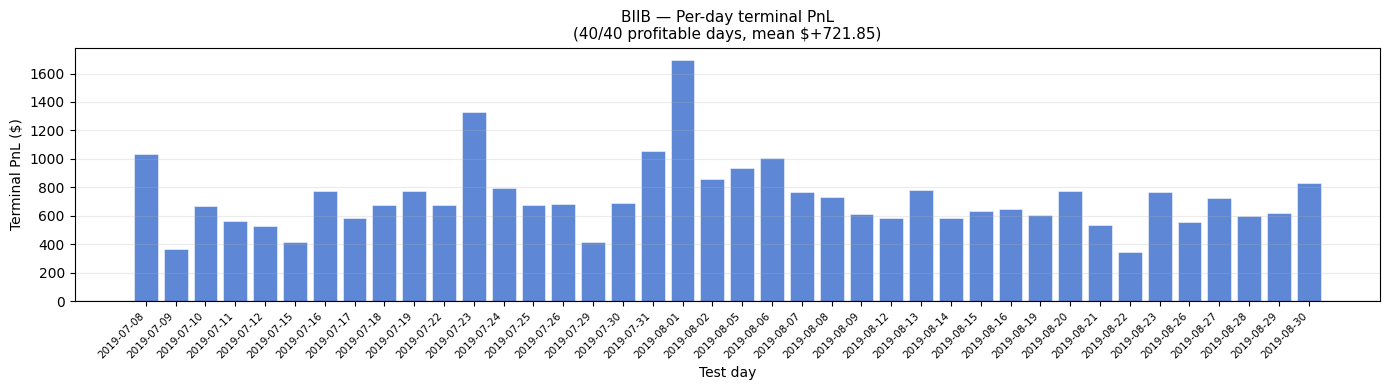

In [9]:
# ---------------------------------------------------------------------------
# Figure C — Per-day terminal PnL  (bar chart, sorted by date)
# ---------------------------------------------------------------------------
dates    = [ds["date"] for ds in day_series]
day_pnls = [float(ds["pnl"].sum()) for ds in day_series]
colors   = ["#4878d0" if p >= 0 else "#d65f5f" for p in day_pnls]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(dates)), day_pnls, color=colors, edgecolor="white", linewidth=0.4, alpha=0.88)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xticks(range(len(dates)))
ax.set_xticklabels(dates, rotation=45, ha="right", fontsize=7.5)
ax.set_xlabel("Test day")
ax.set_ylabel("Terminal PnL ($)")
ax.set_title(f"{SYMBOL} — Per-day terminal PnL\n"
             f"({sum(p>0 for p in day_pnls)}/{len(day_pnls)} profitable days, "
             f"mean ${np.mean(day_pnls):+,.2f})", fontsize=11)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
plt.savefig(os.path.join(CKPT, f"{SYMBOL}_pnl_per_day.png"), dpi=150, bbox_inches="tight")
plt.show()